### Step 1: Data Collection

In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [100]:
image_paths = [
    "data/train/train1.jpg",
    "data/train/train2.jpg",
    "data/train/train3.jpg",
    "data/train/train4.jpg",
    "data/train/train5.jpg",
    "data/train/train6.jpg",
    "data/train/train7.jpg",
    "data/train/train8.jpg",
    "data/train/train9.jpg",
    "data/train/train10.jpg",
    "data/train/train11.jpg",
    "data/train/train12.jpg",
    "data/train/train13.jpg",
    "data/train/train14.jpg",
    "data/train/train15.jpg",
    "data/train/train16.jpg",
    "data/train/train17.jpg",
    "data/train/train18.jpg",
    "data/train/train19.jpg",
    "data/train/train20.jpg"  ]
  

images = []

for path in image_paths:
    img = cv2.imread(path)
    
    if img is not None:
        images.append(img)

print("Loaded images:", len(images))

Loaded images: 20


### Step 02 : Convert to Chromaticity Space

In [101]:
chromaticity_images = []

for img in images:
    
    # Convert BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]
    
    sum_rgb = R + G + B
    sum_rgb[sum_rgb == 0] = 1
    
    x = R / sum_rgb
    y = G / sum_rgb
    
    chromaticity_images.append((x, y))
    
print("Chromaticity conversion done for all images")

Chromaticity conversion done for all images


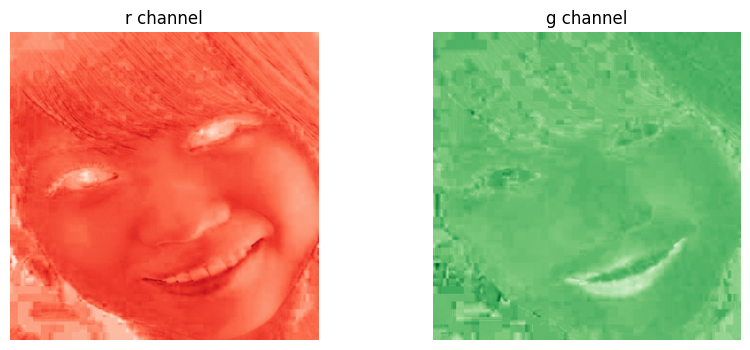

In [102]:
r, g = chromaticity_images[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(r, cmap="Reds")
plt.title("r channel")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(g, cmap="Greens")
plt.title("g channel")
plt.axis("off")

plt.show()

### Step 3: Skin Region Selection
---- Single Image Sectioning for Getting Correct area to crop----

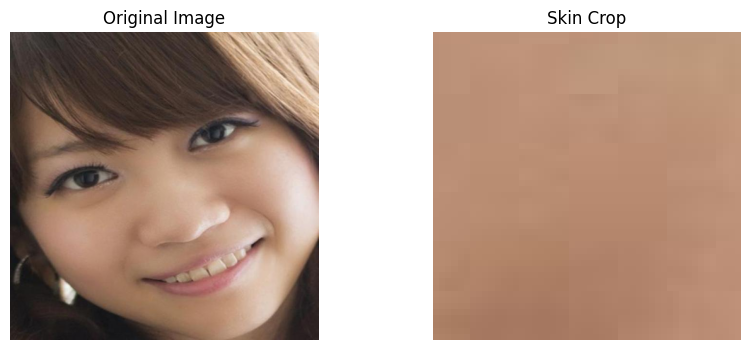

In [103]:
img = cv2.imread("data/train/train1.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x1, x2, y1, y2 = 350, 400, 250, 300

crop = img_rgb[x1:x2, y1:y2]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop)
plt.title("Skin Crop")
plt.axis("off")

plt.show()

In [104]:
cv2.imwrite("data/skin_patches/crop_1.jpg", crop)

True

Total loaded patches: 20


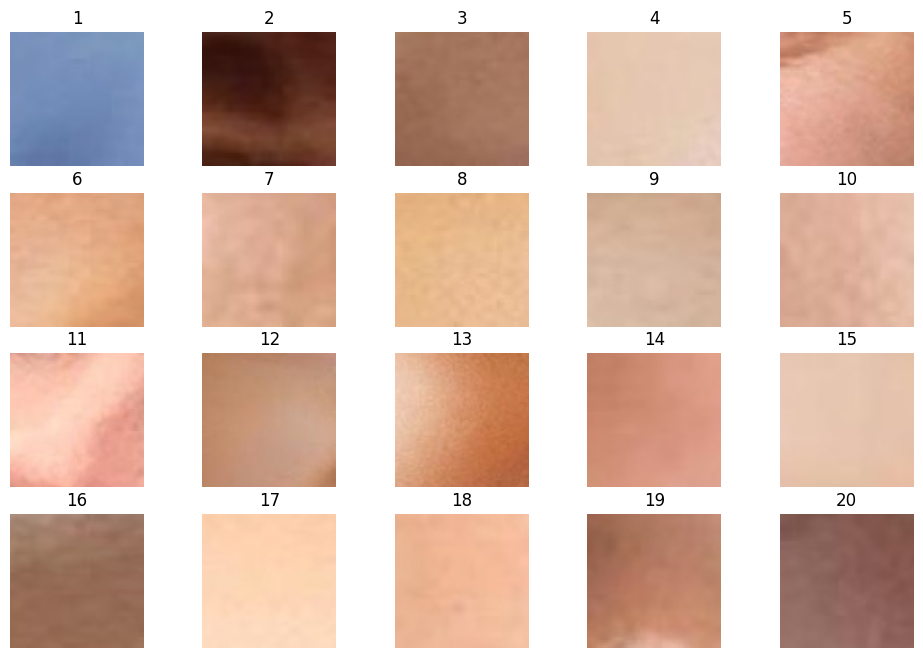

In [126]:
skin_crops = []

for i in range(1, 21): 
    
    path = f"data/skin_patches/crop_{i}.jpg"
    
    img = cv2.imread(path)
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        skin_crops.append(img_rgb)
    else:
        print(f"Missing file: {path}")

print("Total loaded patches:", len(skin_crops))

plt.figure(figsize=(12,8))

for i, crop in enumerate(skin_crops):
    plt.subplot(4, 5, i+1)
    plt.imshow(crop)
    plt.title(i+1)
    plt.axis("off")

plt.show()

### Step 4: Build Skin Color Model

In [107]:
all_skin_pixels = []

for crop in skin_crops:
    
    crop = crop.astype(np.float32)
    
    height, width, channels = crop.shape
    
    for x in range(height):
        for y in range(width):
            
            R = crop[x, y, 0]
            G = crop[x, y, 1]
            B = crop[x, y, 2]
            
            total = R + G + B
            
            if total == 0:
                total = 1
            
            r = R / total
            g = G / total
            
            all_skin_pixels.append([r, g])

# Convert to numpy array
all_skin_pixels = np.array(all_skin_pixels)

print("Final dataset shape:", all_skin_pixels.shape)

Final dataset shape: (93200, 2)


In [108]:
mean_vector = np.mean(all_skin_pixels, axis=0)

print("Mean vector:", mean_vector)

Mean vector: [0.42340568 0.3140217 ]


In [109]:
cov_matrix = np.cov(all_skin_pixels.T)

print("Covariance matrix:\n", cov_matrix)

Covariance matrix:
 [[ 0.00218376 -0.00042293]
 [-0.00042293  0.00017479]]


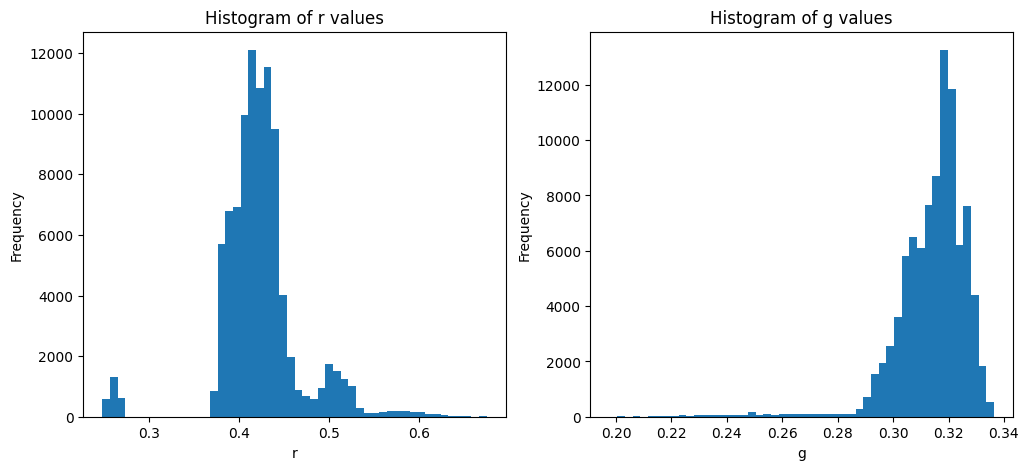

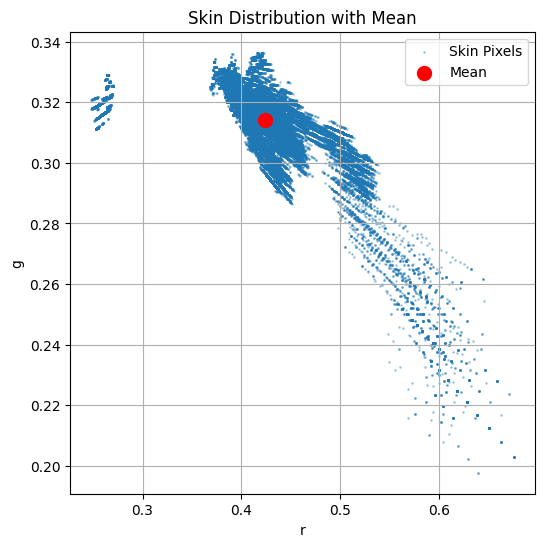

In [130]:
r_values = all_skin_pixels[:, 0]
g_values = all_skin_pixels[:, 1]

plt.figure(figsize=(12,5))

# Histogram for r
plt.subplot(1,2,1)
plt.hist(r_values, bins=50)
plt.title("Histogram of r values")
plt.xlabel("r")
plt.ylabel("Frequency")

# Histogram for g
plt.subplot(1,2,2)
plt.hist(g_values, bins=50)
plt.title("Histogram of g values")
plt.xlabel("g")
plt.ylabel("Frequency")

plt.figure(figsize=(6,6))
plt.scatter(r_values, g_values, s=1, alpha=0.3, label="Skin Pixels")

# mean point
plt.scatter(mean_vector[0], mean_vector[1], color='red', s=100, label="Mean")

plt.xlabel("r")
plt.ylabel("g")
plt.title("Skin Distribution with Mean")

plt.legend()
plt.grid(True)

plt.show()

### Step 5: Skin Detection

In [111]:
test_img = cv2.imread("data/test/test3.jpg")
test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_rgb = test_rgb.astype(np.float32)

height, width, _ = test_rgb.shape

r_img = np.zeros((height, width), dtype=np.float32)
g_img = np.zeros((height, width), dtype=np.float32)

for x in range(height):
    for y in range(width):
        R = test_rgb[x, y, 0]
        G = test_rgb[x, y, 1]
        B = test_rgb[x, y, 2]

        total = R + G + B
        
        if total == 0:
            total = 1

        r_img[x, y] = R / total
        g_img[x, y] = G / total

In [112]:
inv_cov = np.linalg.inv(cov_matrix)

skin_mask = np.zeros((height, width), dtype=np.uint8)

threshold = 1.8

for x in range(height):
    for y in range(width):
        pixel = np.array([r_img[x, y], g_img[x, y]])

        diff = pixel - mean_vector
        distance = np.sqrt(diff.T @ inv_cov @ diff)

        if distance < threshold:
            skin_mask[x, y] = 255
        else:
            skin_mask[x, y] = 0

### Step 6: Visualization

Show skin regions on the original image

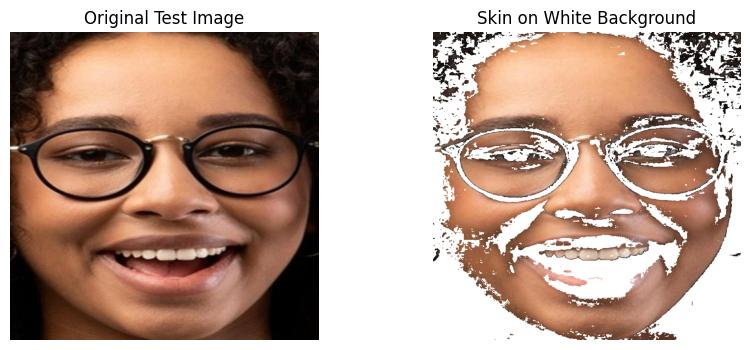

In [113]:
result = np.ones_like(test_rgb, dtype=np.uint8) * 255  # white image

result[skin_mask == 255] = test_rgb[skin_mask == 255]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(test_rgb.astype(np.uint8))
plt.title("Original Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Skin on White Background")
plt.axis("off")

plt.show()

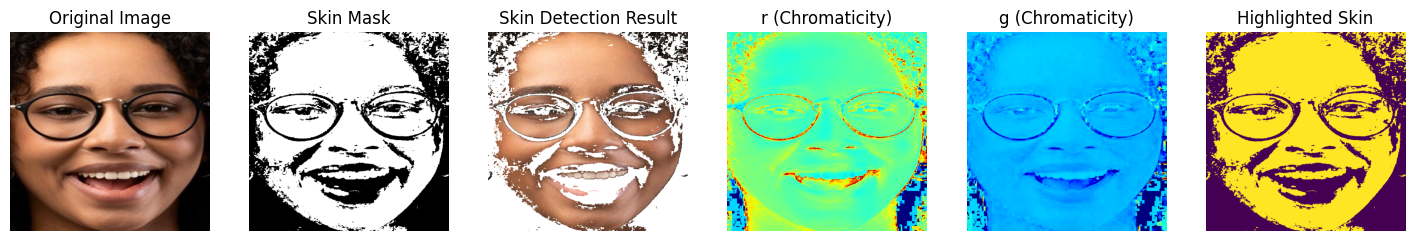

In [120]:
highlight = test_rgb.copy().astype(np.uint8)
highlight[skin_mask == 255] = [0, 255, 0]

plt.figure(figsize=(18,6)) 

plt.subplot(1,6,1)
plt.imshow(test_rgb.astype(np.uint8))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,6,2)
plt.imshow(skin_mask, cmap="gray")
plt.title("Skin Mask")
plt.axis("off")

plt.subplot(1,6,3)
plt.imshow(result)
plt.title("Skin Detection Result")
plt.axis("off")

plt.subplot(1,6,6)
plt.imshow(skin_mask, cmap="viridis")
plt.title("Highlighted Skin")
plt.axis("off")

plt.subplot(1,6,4)
plt.imshow(r_img, cmap="jet")
plt.title("r (Chromaticity)")
plt.axis("off")

plt.subplot(1,6,5)
plt.imshow(g_img, cmap="jet")
plt.title("g (Chromaticity)")
plt.axis("off")

plt.show()

### Step 7: Analysis

#### 1. Sensitivity to Lighting Conditions

The performance of the skin detection system is influenced by lighting conditions. Changes in illumination can affect the RGB values of pixels significantly. For example, strong lighting may increase brightness, while shadows may reduce intensity, causing variations in pixel values.

Although chromaticity reduces the effect of brightness by normalizing RGB values, it is not completely immune to lighting changes. Extreme lighting conditions, such as very bright light or strong shadows, can still alter the color ratios and lead to incorrect classification of skin and non-skin pixels.

Therefore, the method performs best under moderate and consistent lighting conditions, while its accuracy may decrease under poor or uneven illumination.

---

#### 2. Effectiveness of Chromaticity Representation

Chromaticity representation improves skin detection by separating color information from intensity. Instead of using raw RGB values, each pixel is normalized into chromaticity coordinates (r, g), which reduces the influence of brightness.

This makes the method more robust compared to directly using RGB values, especially when dealing with variations in lighting. Skin pixels tend to cluster in a specific region in chromaticity space, making it easier to model them using statistical methods such as mean and covariance.

Overall, chromaticity provides a more stable and reliable representation for skin color detection compared to raw color values.

---

#### 3. Comparison with Simpler Methods (RGB Ratios)

A simpler approach to skin detection is to use fixed RGB thresholds or ratios (for example, conditions like R > G > B). While these methods are easy to implement, they are less flexible and do not generalize well across different skin tones and lighting conditions.

In contrast, the chromaticity-based method uses a statistical model (mean and covariance) to represent the distribution of skin pixels. This allows the system to adapt better to variations in skin color and provides more accurate classification.

However, RGB-based methods are computationally simpler and faster, while chromaticity-based methods require additional calculations and modeling. Despite this, chromaticity-based detection generally produces more reliable results.

---

#### Conclusion

The chromaticity-based skin detection method provides a good balance between simplicity and effectiveness. It reduces sensitivity to lighting compared to raw RGB methods and allows for statistical modeling of skin color. However, it still has limitations under extreme lighting conditions and may produce errors in complex backgrounds.